In [38]:
# Standard imports
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

In [39]:
sys.path.append(r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/pumat")

from lib.Load_Classes.Popular_Load_Class import PopularPath
from lib.Driver_Classes.Mod_Driver_Setup import DriverModelSetup
from lib.Driver_Classes.Mod_Driver_Model import DriverModel
from lib.general_functions.executing_runs import generate_batch_script, run_batch_script

In [40]:
trx_strain = "TriaxialE1"

load_params = {
    "ninc": 5000,
    "maxiter": 50, # Not sure why this can't be zero (Even though pretty sure incremental driver turns it into 5 anyway), don't have this situation for MCSS
    "dtime"  : 0.01,
    "every"  : 10,
    "ddstran_1": 0.2,
}


load = PopularPath(trx_strain, load_params)

In [41]:
# This needs to be in the order that the parameters should be in

Newton_Raphson_Props = {
    "Init Shear Modulus" : 2500,
    "poisson ratio"      : 0.2,
    "M_tc"               : 1,
    "Nova's N"           : 0.0,
    "D_min"              : 0,
    "h"                  : 0,
    "alpha_K"            : 0.1,
    "alpha_G"            : 0.04, 
    "alpha_D"            : 0.04,
    "D_part"             : 0.32, 
    "G_s"                : 2.68,
    "ref_rate"           : 2.5e-5,
    "switch_smooth"      : 0.0, 
    "Num smoothing"      : 0.0,
    "switch original"    : 0.0,
    "FTOl"               : 1e-8,
    "max stress iters"   : 1000,
    "switch_plastic_integration": 0# 0 for substepping and 1 for ortiz-Simo
}

# Store a copy of the properties
Ortiz_Simo_Props = Newton_Raphson_Props.copy()

# Change the integration flag to be Ortiz-Simo integration
Ortiz_Simo_Props["switch_plastic_integration"] = 1




In [42]:
# Make some properties that are perfectly plastic for comparison
Ortiz_Simo_Perf_Plastic_Props = {
    "Init Shear Modulus" : 2500,
    "poisson ratio"      : 0.2,
    "M_tc"               : 1,
    "Nova's N"           : 0.0,
    "D_min"              : 0.0,
    "h"                  : 0.0,
    "alpha_K"            : 0.0,
    "alpha_G"            : 0.0, 
    "alpha_D"            : 0.0,
    "D_part"             : 0.0, 
    "G_s"                : 0.0,
    "ref_rate"           : 0.0,
    "switch_smooth"      : 0.0, 
    "Num smoothing"      : 0.0,
    "switch original"    : 0.0,
    "FTOl"               : 1e-8,
    "max stress iters"   : 1000,
    "switch_plastic_integration": 0# 0 for substepping and 1 for ortiz-Simo
}

In [43]:
# Get the name of the current folder
current_working_dir = os.getcwd()

# Path to the folder that the Ortiz-Simo data should be stored in
Ortiz_Simo = os.path.join(current_working_dir, "Ortiz_Simo")
Newton_Raphson = os.path.join(current_working_dir, "Newton_Raphson")
Ortiz_Simo_Perf_Plastic = os.path.join(current_working_dir, "OS_Perf_Plastic")

exe_path = r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/Strain_Rate_Mohr_Coulomb/build/gfortran_E167FD2A985B468F/app/SRMC_incrementalDriver"


In [44]:
# Generate the 
models = [
          DriverModel(Ortiz_Simo_Perf_Plastic, "OS_Perf_Plastic", exe_path, "output.txt"),
          DriverModel(Ortiz_Simo, "Ortiz_Simo", exe_path, "output.txt"),
          DriverModel(Newton_Raphson, "Newton Raphson", exe_path, "output.txt")
]

# Make a list of the properties and store them for later. Needs to be in the same order as the above models list
properties = [Ortiz_Simo_Perf_Plastic_Props, Ortiz_Simo_Props, Newton_Raphson_Props]

In [45]:
for model in models:
    model.setup.clear_folder()

Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/initialconditions.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/test.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/parameters.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/run_model.bat
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/output.txt
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Ortiz_Simo/initialconditions.inp
Deleted: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Ortiz_Simo/test.inp
Delet

In [46]:

for model, props in zip(models, properties):
    model.setup.write_parameters_file(props)


In [47]:
# Set the stress and state parameters
stress = [-100, -100, -100, 0, 0, 0]
state_params = {"shear modulus"       : 0,
                "bulk modulus"        : 0,
                "Stress ratio"        : 0,
                "Dilatancy"           : 0,
                "Inertial Coeff"      : 0,
                "yielding (1 for yes)": 0,
                "EspP_1"              : 0,
                "EspP_2"              : 0,
                "EspP_3"              : 0,
                "EspP_4"              : 0,
                "EspP_5"              : 0,
                "EspP_6"              : 0,
                "N_i"                 : 0, # Current number of strain rate sums
                "Sum_rate"            : 0  # Current sum of strain rates 
}

for model in models:
    model.setup.write_initial_conditions_file(stress, state_params)
    model.setup.store_loads(load)
    model.setup.write_loads()

In [48]:
for model in models:
    model.run_model()

Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic/run_model.bat' executed successfully.
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Ortiz_Simo/run_model.bat' executed successfully.
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Newton_Raphson/run_model.bat' executed successfully.


In [49]:
for model in models:
    print(model.results)

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/OS_Perf_Plastic

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Ortiz_Simo

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/Newton_Raphson



In [50]:
for model in models:
    model.results.store_all()

## Dilatancy information

The formulation for dilatancy in the model is:

$$D^{p} = D^{p}_{min} h \varepsilon_{q}^{p} \exp(1 - h \varepsilon_{q}^{p})$$

This means that when the plastic strain and hence the deviatoric strain invariant gets high the dilatancy approaches zero.

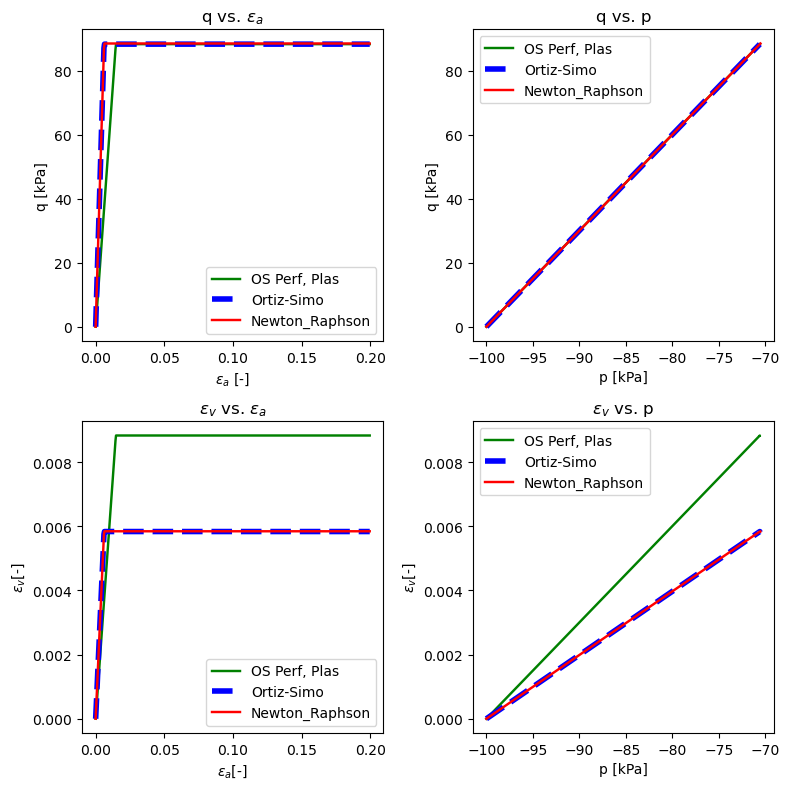

In [51]:
# Generate a figure to plot the MCSS models
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8, 8))

colors = ["green", "blue", "red"]
labels = ["OS Perf, Plas", "Ortiz-Simo", 'Newton_Raphson']
styles = ["solid", "dashed", "solid"]
line_widths = [1.75, 4, 1.75]

for model, color, label, style, linewidth in zip(models, colors, labels, styles, line_widths):
    model.results.quick_quad_plot(axial_strain_id="stran(1)", compression_pos=False, axs = axs, 
                                  color = color , label=label, legend = True, linestyle = style, linewidth = linewidth)
    
plt.show()
# fig.savefig("Drained_Strain_Control_linear_elastic.png", format = "png", bbox_inches = 'tight')
plt.close()

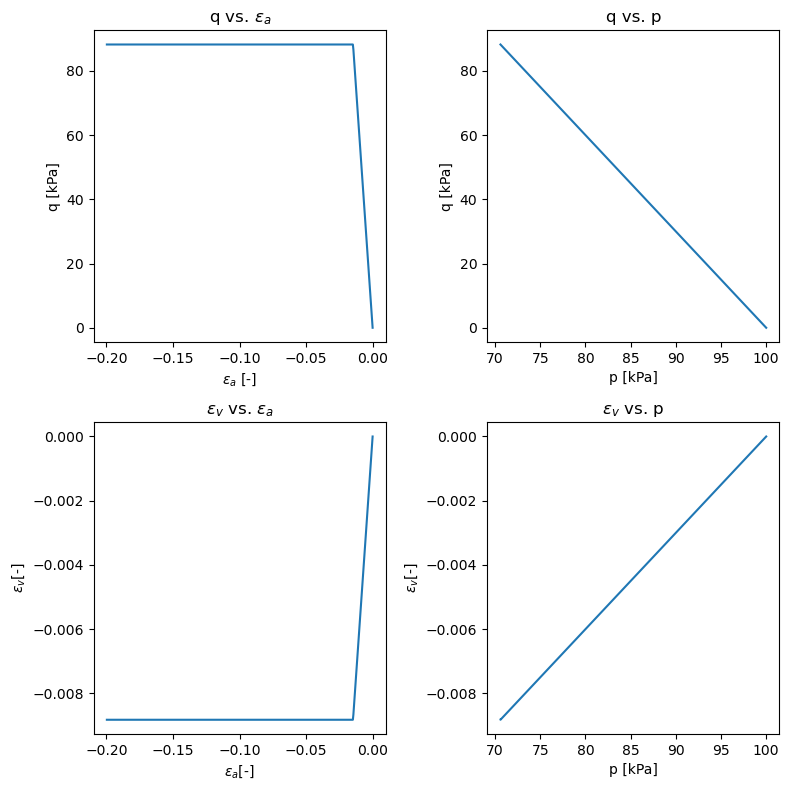

In [52]:
models[0].results.quick_quad_plot(figsize = (8,8))

In [53]:
models[0].results.stress_df

,stress(1),stress(2),stress(3),stress(4),stress(5),stress(6)
0,-100.000000,-100.0,-100.0,0.0,0.0,0.0
1,-99.760000,-100.0,-100.0,0.0,0.0,0.0
2,-97.360000,-100.0,-100.0,0.0,0.0,0.0
3,-94.960000,-100.0,-100.0,0.0,0.0,0.0
4,-92.560000,-100.0,-100.0,0.0,0.0,0.0
...,...,...,...,...,...,...
496,-11.764706,-100.0,-100.0,0.0,0.0,0.0
497,-11.764706,-100.0,-100.0,0.0,0.0,0.0
498,-11.764706,-100.0,-100.0,0.0,0.0,0.0
499,-11.764706,-100.0,-100.0,0.0,0.0,0.0


In [54]:
models[1].results.stress_df

,stress(1),stress(2),stress(3),stress(4),stress(5),stress(6)
0,-100.000000,-100.0,-100.0,0.0,0.0,0.0
1,-99.427656,-100.0,-100.0,0.0,0.0,0.0
2,-93.701807,-100.0,-100.0,0.0,0.0,0.0
3,-87.971522,-100.0,-100.0,0.0,0.0,0.0
4,-82.236706,-100.0,-100.0,0.0,0.0,0.0
...,...,...,...,...,...,...
496,-11.764706,-100.0,-100.0,0.0,0.0,0.0
497,-11.764706,-100.0,-100.0,0.0,0.0,0.0
498,-11.764706,-100.0,-100.0,0.0,0.0,0.0
499,-11.764706,-100.0,-100.0,0.0,0.0,0.0


In [55]:
models[0].results.strain_df

,stran(1),stran(2),stran(3),stran(4),stran(5),stran(6)
0,0.00000,0.000000,0.000000,0.0,0.0,0.0
1,0.00004,-0.000008,-0.000008,0.0,0.0,0.0
2,0.00044,-0.000088,-0.000088,0.0,0.0,0.0
3,0.00084,-0.000168,-0.000168,0.0,0.0,0.0
4,0.00124,-0.000248,-0.000248,0.0,0.0,0.0
...,...,...,...,...,...,...
496,0.19804,-0.094607,-0.094607,0.0,0.0,0.0
497,0.19844,-0.094807,-0.094807,0.0,0.0,0.0
498,0.19884,-0.095007,-0.095007,0.0,0.0,0.0
499,0.19924,-0.095207,-0.095207,0.0,0.0,0.0
